------------
### <center> Car Sales Prediction-- Linear Regression </center>
------------

#### Import Packages:

In [1]:
# data handling packages
import numpy as np
import pandas as pd

# visualization packages
import seaborn as sns
import matplotlib.pyplot as plt

import scipy.stats as stats  # hypothesis testing

# statistical modelling
import statsmodels.formula.api as smf

# subpackages from sklearn for data handling, variable selection and model evaluation
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error

# for modelling - stats and ML
import sklearn
from sklearn.linear_model import LinearRegression

#### Data Import:

In [2]:
cars = pd.read_csv("D:\Python Content\Old- Current Curriculum\STUDY MATERIAL\Car_sales.csv")
cars.head(3)

,Manufacturer,Model,Sales_in_thousands,four_year_resale_value,Vehicle_type,Price_in_thousands,Engine_size,Horsepower,Wheelbase,Width,Length,Curb_weight,Fuel_capacity,Fuel_efficiency,Latest_Launch,Power_perf_factor
0,Acura,Integra,16.919,16.360,Passenger,21.5,1.8,140.0,101.2,67.3,172.4,2.639,13.2,28.0,02-02-2012,58.280150
1,Acura,TL,39.384,19.875,Passenger,28.4,3.2,225.0,108.1,70.3,192.9,3.517,17.2,25.0,06-03-2011,91.370778
2,Acura,CL,14.114,18.225,Passenger,NaN,3.2,225.0,106.9,70.6,192.0,3.470,17.2,26.0,01-04-2012,NaN


#### Data understanding | EDA:

In [3]:
cars.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 157 entries, 0 to 156
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Manufacturer            157 non-null    object 
 1   Model                   157 non-null    object 
 2   Sales_in_thousands      157 non-null    float64
 3   four_year_resale_value  121 non-null    float64
 4   Vehicle_type            157 non-null    object 
 5   Price_in_thousands      155 non-null    float64
 6   Engine_size             156 non-null    float64
 7   Horsepower              156 non-null    float64
 8   Wheelbase               156 non-null    float64
 9   Width                   156 non-null    float64
 10  Length                  156 non-null    float64
 11  Curb_weight             155 non-null    float64
 12  Fuel_capacity           156 non-null    float64
 13  Fuel_efficiency         154 non-null    float64
 14  Latest_Launch           157 non-null    ob

##### 1. No. of rows & columns :

In [4]:
print("No. of observations in dataset = ", cars.shape[0] )
print("No. of variables in dataset = ", cars.shape[1] )

No. of observations in dataset =  157
No. of variables in dataset =  16


##### 2. Fetching Categorical data:

In [5]:
cars.loc[ : :, ['Manufacturer','Model', 'Vehicle_type'] ]

,Manufacturer,Model,Vehicle_type
0,Acura,Integra,Passenger
1,Acura,TL,Passenger
2,Acura,CL,Passenger
3,Acura,RL,Passenger
4,Audi,A4,Passenger
...,...,...,...
152,Volvo,V40,Passenger
153,Volvo,S70,Passenger
154,Volvo,V70,Passenger
155,Volvo,C70,Passenger


##### 3. Cardinality of each categorical data:

In [6]:
print("No. of manufacturers = ", cars.Manufacturer.nunique() )

No. of manufacturers =  30


In [7]:
cars.Manufacturer.value_counts()

Manufacturer
Dodge         11
Ford          11
Toyota         9
Chevrolet      9
Mercedes-B     9
Mitsubishi     7
Nissan         7
Chrysler       7
Volvo          6
Oldsmobile     6
Lexus          6
Mercury        6
Pontiac        6
Volkswagen     6
Saturn         5
Cadillac       5
Honda          5
Plymouth       4
Acura          4
Buick          4
Audi           3
Jeep           3
Porsche        3
Hyundai        3
BMW            3
Lincoln        3
Saab           2
Subaru         2
Jaguar         1
Infiniti       1
Name: count, dtype: int64

In [8]:
print("No. of car models = ", cars.Model.nunique() )

No. of car models =  156


In [9]:
print("No. of different vehicle types = ", cars.Vehicle_type.nunique() )

No. of different vehicle types =  2


In [10]:
cars.Vehicle_type.value_counts()

Vehicle_type
Passenger    116
Car           41
Name: count, dtype: int64

##### 4. Descriptive analysis of Continuous data:

In [11]:
cars.describe().T

,count,mean,std,min,25%,50%,75%,max
Sales_in_thousands,157.0,52.998076,68.029422,0.110000,14.114000,29.450000,67.956000,540.561000
four_year_resale_value,121.0,18.072975,11.453384,5.160000,11.260000,14.180000,19.875000,67.550000
Price_in_thousands,155.0,27.390755,14.351653,9.235000,18.017500,22.799000,31.947500,85.500000
Engine_size,156.0,3.060897,1.044653,1.000000,2.300000,3.000000,3.575000,8.000000
Horsepower,156.0,185.948718,56.700321,55.000000,149.500000,177.500000,215.000000,450.000000
Wheelbase,156.0,107.487179,7.641303,92.600000,103.000000,107.000000,112.200000,138.700000
Width,156.0,71.150000,3.451872,62.600000,68.400000,70.550000,73.425000,79.900000
Length,156.0,187.343590,13.431754,149.400000,177.575000,187.900000,196.125000,224.500000
Curb_weight,155.0,3.378026,0.630502,1.895000,2.971000,3.342000,3.799500,5.572000
Fuel_capacity,156.0,17.951923,3.887921,10.300000,15.800000,17.200000,19.575000,32.000000


##### 5. Check for missing data:

In [12]:
cars.isna().sum()       # no. of missing values in each column.

Manufacturer               0
Model                      0
Sales_in_thousands         0
four_year_resale_value    36
Vehicle_type               0
Price_in_thousands         2
Engine_size                1
Horsepower                 1
Wheelbase                  1
Width                      1
Length                     1
Curb_weight                2
Fuel_capacity              1
Fuel_efficiency            3
Latest_Launch              0
Power_perf_factor          2
dtype: int64

In [13]:
cars.isna().sum() / cars.shape[0] *100     #  %age of missing values in each column

Manufacturer               0.000000
Model                      0.000000
Sales_in_thousands         0.000000
four_year_resale_value    22.929936
Vehicle_type               0.000000
Price_in_thousands         1.273885
Engine_size                0.636943
Horsepower                 0.636943
Wheelbase                  0.636943
Width                      0.636943
Length                     0.636943
Curb_weight                1.273885
Fuel_capacity              0.636943
Fuel_efficiency            1.910828
Latest_Launch              0.000000
Power_perf_factor          1.273885
dtype: float64

##### 6. Performing hypothetical relationship analysis:

* If horsepower is high, so is the engine size, price of the car, length of the car, width, fuel capacity.
* But, fuel efficiency will be low,.......

* Here, we are not performing any manipulations or task, just a hypothesis.

##### 7. Checking the relationship between X variables:

In [14]:
Continuous_Var_Relationships = cars.select_dtypes('float64').corr()
Continuous_Var_Relationships.to_excel("D:\Python Batches\Weekend Feb 2026\Corelations_analysis_LR.xlsx")

<Axes: >

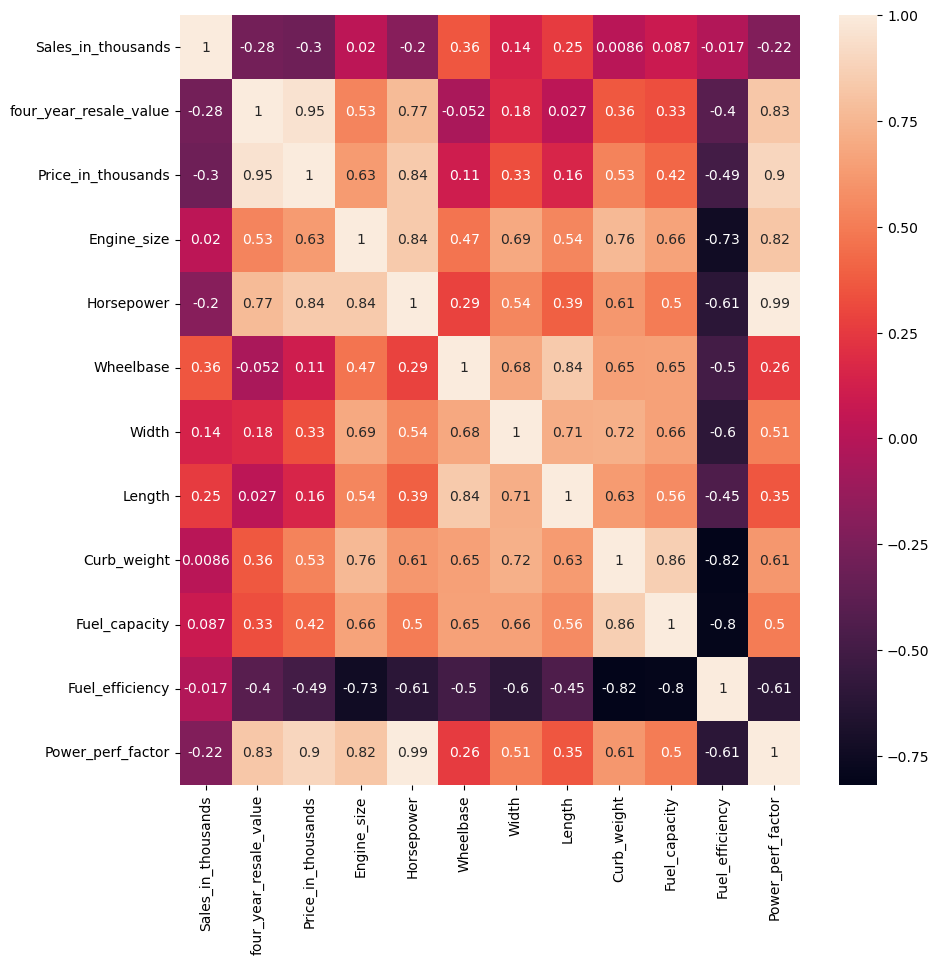

In [15]:
plt.figure(figsize= (10,10))
sns.heatmap(Continuous_Var_Relationships, annot = True)

* For better & efficient data cleaning, let's split the data as per data types using  ***select_dtypes()***.

In [16]:
cars_object =  cars.select_dtypes('object')
cars_numeric =  cars.select_dtypes('float64')

In [17]:
cars_object.head(3)

,Manufacturer,Model,Vehicle_type,Latest_Launch
0,Acura,Integra,Passenger,02-02-2012
1,Acura,TL,Passenger,06-03-2011
2,Acura,CL,Passenger,01-04-2012


In [18]:
cars_numeric.head(3)

,Sales_in_thousands,four_year_resale_value,Price_in_thousands,Engine_size,Horsepower,Wheelbase,Width,Length,Curb_weight,Fuel_capacity,Fuel_efficiency,Power_perf_factor
0,16.919,16.360,21.5,1.8,140.0,101.2,67.3,172.4,2.639,13.2,28.0,58.280150
1,39.384,19.875,28.4,3.2,225.0,108.1,70.3,192.9,3.517,17.2,25.0,91.370778
2,14.114,18.225,NaN,3.2,225.0,106.9,70.6,192.0,3.470,17.2,26.0,NaN


##### 8. Check outliers, missings & duplicates for all the continuous data: (EDA on continuous data)

In [19]:
def continuous_var_summary( x ):
    
    # freq and missings
    n_total = x.shape[0]                   # total observations/rows in a column
    n_miss = x.isna().sum()                # count of missing values in a column
    perc_miss = n_miss * 100 / n_total     # %age of missing values in a column
    
    # outliers - iqr
    q1 = x.quantile(0.25)
    q3 = x.quantile(0.75)
    iqr = q3 - q1
    lc_iqr = q1 - 1.5 * iqr
    uc_iqr = q3 + 1.5 * iqr
    
    return pd.Series( [ x.dtype, x.nunique(), n_total, x.count(), n_miss, perc_miss,
                       x.sum(), x.mean(), x.std(), x.var(), 
                       lc_iqr, uc_iqr, 
                       x.min(), x.quantile(0.01), x.quantile(0.05), x.quantile(0.10), 
                       x.quantile(0.25), x.quantile(0.5), x.quantile(0.75), 
                       x.quantile(0.90), x.quantile(0.95), x.quantile(0.99), x.max() ], 
                     
                    index = ['dtype', 'cardinality', 'n_tot', 'n', 'nmiss', 'perc_miss',
                             'sum', 'mean', 'std', 'var',
                        'lc_iqr', 'uc_iqr',
                        'min', 'p1', 'p5', 'p10', 'p25', 'p50', 'p75', 'p90', 'p95', 'p99', 'max']) 

In [20]:
cars_numeric.apply(continuous_var_summary)

,Sales_in_thousands,four_year_resale_value,Price_in_thousands,Engine_size,Horsepower,Wheelbase,Width,Length,Curb_weight,Fuel_capacity,Fuel_efficiency,Power_perf_factor
dtype,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
cardinality,157,117,152,31,66,88,78,127,147,55,20,154
n_tot,157,157,157,157,157,157,157,157,157,157,157,157
n,157,121,155,156,156,156,156,156,155,156,154,155
nmiss,0,36,2,1,1,1,1,1,2,1,3,2
perc_miss,0.0,22.929936,1.273885,0.636943,0.636943,0.636943,0.636943,0.636943,1.273885,0.636943,1.910828,1.273885
sum,8320.698,2186.83,4245.567,477.5,29008.0,16768.0,11099.4,29225.6,523.594,2800.5,3672.0,11941.756636
mean,52.998076,18.072975,27.390755,3.060897,185.948718,107.487179,71.15,187.34359,3.378026,17.951923,23.844156,77.043591
std,68.029422,11.453384,14.351653,1.044653,56.700321,7.641303,3.451872,13.431754,0.630502,3.887921,4.282706,25.142664
var,4628.002257,131.180007,205.969949,1.0913,3214.926385,58.389512,11.915419,180.412023,0.397532,15.115932,18.341567,632.153558


##### 9. EDA on Categorical Data:

In [21]:
cars_object.describe()

,Manufacturer,Model,Vehicle_type,Latest_Launch
count,157,157,157,157
unique,30,156,2,130
top,Dodge,Neon,Passenger,10-05-2012
freq,11,2,116,2


##### 10. Data Cleaning:

* Data Transformations on continuous data will include:

          i. Outlier treatment
          ii. Missing value treatment
          iii. Dummy Variables for categorical data.         

###### a. Outlier Treatment using *.clip(lower = , upper = )*:

In [22]:
cars_numeric = cars_numeric.apply( lambda x : x.clip( lower = x.quantile(0.01), 
                                      upper = x.quantile(0.99) ) )

# Treating outliers using %tile method.

###### b. Handle missing values through imputation using the mean of the column via fillna():

In [23]:
cars_numeric = cars_numeric.apply( lambda x: x.fillna(x.mean()) )

In [24]:
cars_numeric.apply(continuous_var_summary)

,Sales_in_thousands,four_year_resale_value,Price_in_thousands,Engine_size,Horsepower,Wheelbase,Width,Length,Curb_weight,Fuel_capacity,Fuel_efficiency,Power_perf_factor
dtype,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
cardinality,155,116,151,30,65,88,77,126,146,55,20,153
n_tot,157,157,157,157,157,157,157,157,157,157,157,157
n,157,157,157,157,157,157,157,157,157,157,157,157
nmiss,0,0,0,0,0,0,0,0,0,0,0,0
perc_miss,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
sum,8025.5292,2829.141298,4290.61297,478.860064,29095.622436,16867.536538,11173.619551,29411.272949,530.528485,2817.848077,3731.298701,12065.384534
mean,51.11802,18.020008,27.328745,3.050064,185.322436,107.436538,71.169551,187.332949,3.379162,17.948077,23.766234,76.849583
std,57.722699,9.80668,13.973525,0.979125,52.646914,7.400461,3.379455,13.07823,0.617766,3.807591,3.956157,23.691622
var,3331.909938,96.170969,195.259402,0.958686,2771.697606,54.766822,11.420718,171.04011,0.381634,14.497753,15.651182,561.292961


* Data Transformation on the categortical data:

    i. create dummy variables using *pd.get_dummies()*

* From the below assumptions, it is clear from point 3 that we need to choose Manufacturer & Vehicle type only for creating dummy variables.

* Limitation:

          It might not follow INC Rules. So check for column named after creating dummy variables.

In [25]:
cars_object = pd.get_dummies( cars_object.loc[ : : , ['Manufacturer', 'Vehicle_type'] ], drop_first= True )
cars_object.columns

Index(['Manufacturer_Audi', 'Manufacturer_BMW', 'Manufacturer_Buick',
       'Manufacturer_Cadillac', 'Manufacturer_Chevrolet',
       'Manufacturer_Chrysler', 'Manufacturer_Dodge', 'Manufacturer_Ford',
       'Manufacturer_Honda', 'Manufacturer_Hyundai', 'Manufacturer_Infiniti',
       'Manufacturer_Jaguar', 'Manufacturer_Jeep', 'Manufacturer_Lexus',
       'Manufacturer_Lincoln', 'Manufacturer_Mercedes-B',
       'Manufacturer_Mercury', 'Manufacturer_Mitsubishi',
       'Manufacturer_Nissan', 'Manufacturer_Oldsmobile',
       'Manufacturer_Plymouth', 'Manufacturer_Pontiac', 'Manufacturer_Porsche',
       'Manufacturer_Saab', 'Manufacturer_Saturn', 'Manufacturer_Subaru',
       'Manufacturer_Toyota', 'Manufacturer_Volkswagen', 'Manufacturer_Volvo',
       'Vehicle_type_Passenger'],
      dtype='object')

In [26]:
cars_object.rename(columns = {'Manufacturer_Mercedes-B' : 'Manufacturer_Mercedes_B'} , inplace = True)

In [27]:
cars_object.columns

Index(['Manufacturer_Audi', 'Manufacturer_BMW', 'Manufacturer_Buick',
       'Manufacturer_Cadillac', 'Manufacturer_Chevrolet',
       'Manufacturer_Chrysler', 'Manufacturer_Dodge', 'Manufacturer_Ford',
       'Manufacturer_Honda', 'Manufacturer_Hyundai', 'Manufacturer_Infiniti',
       'Manufacturer_Jaguar', 'Manufacturer_Jeep', 'Manufacturer_Lexus',
       'Manufacturer_Lincoln', 'Manufacturer_Mercedes_B',
       'Manufacturer_Mercury', 'Manufacturer_Mitsubishi',
       'Manufacturer_Nissan', 'Manufacturer_Oldsmobile',
       'Manufacturer_Plymouth', 'Manufacturer_Pontiac', 'Manufacturer_Porsche',
       'Manufacturer_Saab', 'Manufacturer_Saturn', 'Manufacturer_Subaru',
       'Manufacturer_Toyota', 'Manufacturer_Volkswagen', 'Manufacturer_Volvo',
       'Vehicle_type_Passenger'],
      dtype='object')

##### 11. Combining Categorical & Continuous Data:
            
            using pd.concat()

In [28]:
cars_new = pd.concat([cars_numeric, cars_object], axis = 1 )
cars_new.head(3)

,Sales_in_thousands,four_year_resale_value,Price_in_thousands,Engine_size,Horsepower,Wheelbase,Width,Length,Curb_weight,Fuel_capacity,...,Manufacturer_Plymouth,Manufacturer_Pontiac,Manufacturer_Porsche,Manufacturer_Saab,Manufacturer_Saturn,Manufacturer_Subaru,Manufacturer_Toyota,Manufacturer_Volkswagen,Manufacturer_Volvo,Vehicle_type_Passenger
0,16.919,16.360,21.500000,1.8,140.0,101.2,67.3,172.4,2.639,13.2,...,False,False,False,False,False,False,False,False,False,True
1,39.384,19.875,28.400000,3.2,225.0,108.1,70.3,192.9,3.517,17.2,...,False,False,False,False,False,False,False,False,False,True
2,14.114,18.225,27.328745,3.2,225.0,106.9,70.6,192.0,3.470,17.2,...,False,False,False,False,False,False,False,False,False,True


#### Linear Regression Model Assumptions:

* LR model is based on lot of assumptions, out of which 10 are critical. We will discuss 4 of these assumptions now:

         i. All variables( X & y variables) must follow Normal Distribution. If not all, then atleast y variable should be Normally Distributed.
         ii. All x variables must be linear to the y variable, else we will not get the straight line for the best fit.  
         iii. No. of observations > No. of x variables.
         iv. X variables should be independent, i.e very less multi-collinearity between x variables.

C:\Users\mehak\AppData\Local\Temp\ipykernel_15736\180685371.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot( cars_new.Sales_in_thousands)


<Axes: xlabel='Sales_in_thousands', ylabel='Density'>

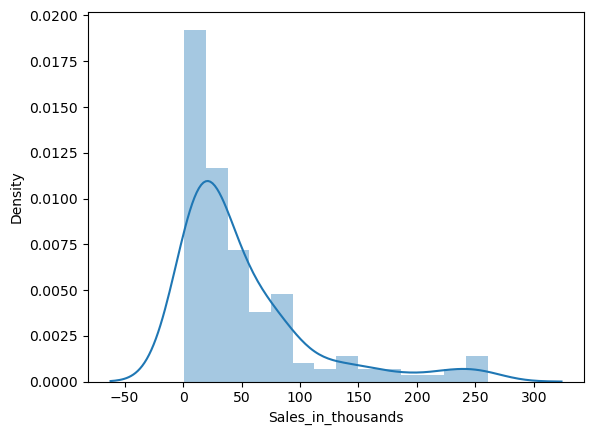

In [29]:
##### 1. check the distribution of y variable:

# a: using visualization
sns.distplot( cars_new.Sales_in_thousands)

In [30]:
# b. using .skew():

cars_new.Sales_in_thousands.skew()

np.float64(1.9924932920508793)

**Note:**

* From the above 2 o/ps it is clear that y variables is not normally distributed. So, we have to make some transformations on the y variable so that it is almost Normally distributed.

* The transformation can be done using *np.log()*
  

In [31]:
cars_new['lg_sales_in_thousands'] = np.log(cars_new.Sales_in_thousands) 

In [32]:
np.log( cars_new.Sales_in_thousands).skew()

np.float64(-0.5925861100519006)

C:\Users\mehak\AppData\Local\Temp\ipykernel_15736\2530140438.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot( np.log(cars_new.Sales_in_thousands) )


<Axes: xlabel='Sales_in_thousands', ylabel='Density'>

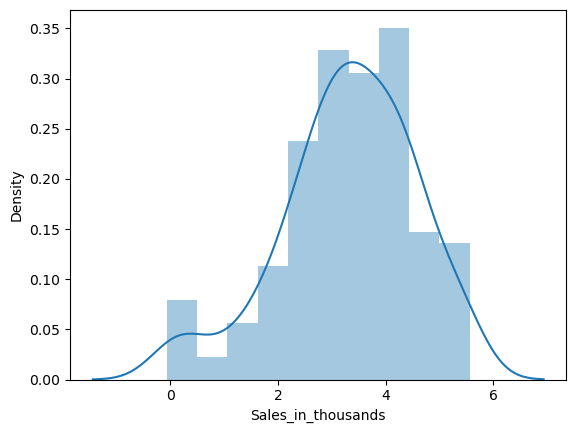

In [33]:
sns.distplot( np.log(cars_new.Sales_in_thousands) )

In [34]:
cars_new.columns

Index(['Sales_in_thousands', 'four_year_resale_value', 'Price_in_thousands',
       'Engine_size', 'Horsepower', 'Wheelbase', 'Width', 'Length',
       'Curb_weight', 'Fuel_capacity', 'Fuel_efficiency', 'Power_perf_factor',
       'Manufacturer_Audi', 'Manufacturer_BMW', 'Manufacturer_Buick',
       'Manufacturer_Cadillac', 'Manufacturer_Chevrolet',
       'Manufacturer_Chrysler', 'Manufacturer_Dodge', 'Manufacturer_Ford',
       'Manufacturer_Honda', 'Manufacturer_Hyundai', 'Manufacturer_Infiniti',
       'Manufacturer_Jaguar', 'Manufacturer_Jeep', 'Manufacturer_Lexus',
       'Manufacturer_Lincoln', 'Manufacturer_Mercedes_B',
       'Manufacturer_Mercury', 'Manufacturer_Mitsubishi',
       'Manufacturer_Nissan', 'Manufacturer_Oldsmobile',
       'Manufacturer_Plymouth', 'Manufacturer_Pontiac', 'Manufacturer_Porsche',
       'Manufacturer_Saab', 'Manufacturer_Saturn', 'Manufacturer_Subaru',
       'Manufacturer_Toyota', 'Manufacturer_Volkswagen', 'Manufacturer_Volvo',
       'Vehicle_

In [35]:
##### 2. X variables must be linear to y variable, i.e. check co-relations:

Linear_corelations = cars_new.corr()
Linear_corelations.to_excel("D:\Python Batches\Weekend Feb 2026\Linear_Corelations.xlsx")

In [36]:
##### 3. No. of observations > No. of X variables:

# X variables are also known as FEATURES.

features = list(cars_new.columns.difference(['Sales_in_thousands', 'lg_sales_in_thousands']))

print("No. of x variables = ", len(features))
print("No. of observations = ", cars_new.shape[0] )

No. of x variables =  41
No. of observations =  157


##### 12. Variable Reduction:

* Choosing only the important X variables for model building. 
* It includes:

      a. Feature importance:
                      choosing only the important & required X variables using f_regression()
                                
      b. Multi Colinearity check:

                      Checking the co-relation between the chosen X variables using dmatrices() & vif()

In [37]:
##### 1. Create X variables, i.e. features:

featured = list( cars_new.columns.difference(['Sales_in_thousands', 'lg_sales_in_thousands']) )
features

['Curb_weight',
 'Engine_size',
 'Fuel_capacity',
 'Fuel_efficiency',
 'Horsepower',
 'Length',
 'Manufacturer_Audi',
 'Manufacturer_BMW',
 'Manufacturer_Buick',
 'Manufacturer_Cadillac',
 'Manufacturer_Chevrolet',
 'Manufacturer_Chrysler',
 'Manufacturer_Dodge',
 'Manufacturer_Ford',
 'Manufacturer_Honda',
 'Manufacturer_Hyundai',
 'Manufacturer_Infiniti',
 'Manufacturer_Jaguar',
 'Manufacturer_Jeep',
 'Manufacturer_Lexus',
 'Manufacturer_Lincoln',
 'Manufacturer_Mercedes_B',
 'Manufacturer_Mercury',
 'Manufacturer_Mitsubishi',
 'Manufacturer_Nissan',
 'Manufacturer_Oldsmobile',
 'Manufacturer_Plymouth',
 'Manufacturer_Pontiac',
 'Manufacturer_Porsche',
 'Manufacturer_Saab',
 'Manufacturer_Saturn',
 'Manufacturer_Subaru',
 'Manufacturer_Toyota',
 'Manufacturer_Volkswagen',
 'Manufacturer_Volvo',
 'Power_perf_factor',
 'Price_in_thousands',
 'Vehicle_type_Passenger',
 'Wheelbase',
 'Width',
 'four_year_resale_value']

##### **Feature Importance:**

In [38]:
# get the significant variables : bi-variate regression

from sklearn.feature_selection import f_regression

# feature_selection subpackage is usedf for feature reduction, i.e. choosing few x variables only.

In [39]:
f_score, p_values = f_regression(cars_new[features], cars_new.lg_sales_in_thousands)

In [40]:
#### Create an empty data frame that stores all the features(X variables), f-score & p-values:

significant_variables = pd.DataFrame()
significant_variables['Features'] = features
significant_variables['F_Score'] = f_score
significant_variables['P_Values'] = p_values
significant_variables

,Features,F_Score,P_Values
0,Curb_weight,0.418695,5.185460e-01
1,Engine_size,2.302434,1.312083e-01
2,Fuel_capacity,0.059260,8.079907e-01
3,Fuel_efficiency,2.877548,9.183014e-02
4,Horsepower,29.616745,2.016940e-07
5,Length,6.954753,9.211207e-03
6,Manufacturer_Audi,2.874313,9.201122e-02
7,Manufacturer_BMW,0.726643,3.952886e-01
8,Manufacturer_Buick,1.196073,2.758046e-01
9,Manufacturer_Cadillac,0.887999,3.474866e-01


**NOTE:** We will keep only those features which are highly significant where the p_values < 0.1

In [41]:
features = list(significant_variables.loc[ significant_variables.P_Values < 0.1, 'Features'].reset_index(drop = True))
features

['Fuel_efficiency',
 'Horsepower',
 'Length',
 'Manufacturer_Audi',
 'Manufacturer_Ford',
 'Manufacturer_Honda',
 'Manufacturer_Mercedes_B',
 'Manufacturer_Plymouth',
 'Manufacturer_Porsche',
 'Manufacturer_Toyota',
 'Manufacturer_Volvo',
 'Power_perf_factor',
 'Price_in_thousands',
 'Vehicle_type_Passenger',
 'Wheelbase',
 'four_year_resale_value']

##### **Multi-Colinearity Check:**

In [42]:
# import the packages for vif

from statsmodels.stats.outliers_influence import variance_inflation_factor
from patsy import dmatrices

In [43]:
model_param =  'lg_sales_in_thousands ~ '  + '+'.join(features)
model_param

'lg_sales_in_thousands ~ Fuel_efficiency+Horsepower+Length+Manufacturer_Audi+Manufacturer_Ford+Manufacturer_Honda+Manufacturer_Mercedes_B+Manufacturer_Plymouth+Manufacturer_Porsche+Manufacturer_Toyota+Manufacturer_Volvo+Power_perf_factor+Price_in_thousands+Vehicle_type_Passenger+Wheelbase+four_year_resale_value'

In [44]:
# separate the Y and X variables
y, X = dmatrices( model_param, cars_new, return_type = 'dataframe' )

# For each X, calculate VIF and save in dataframe
vif = pd.DataFrame()

vif['Features'] = X.columns  # adding new column called "Features" which consists of all X variables(16) created in above step
vif['VIF Factor'] = [ variance_inflation_factor(X.values, i) for i in range( X.shape[1] ) ]
vif

,Features,VIF Factor
0,Intercept,644.058154
1,Manufacturer_Audi[T.True],1.073516
2,Manufacturer_Ford[T.True],1.091235
3,Manufacturer_Honda[T.True],1.092045
4,Manufacturer_Mercedes_B[T.True],1.722476
5,Manufacturer_Plymouth[T.True],1.181433
6,Manufacturer_Porsche[T.True],1.675094
7,Manufacturer_Toyota[T.True],1.173508
8,Manufacturer_Volvo[T.True],1.078381
9,Vehicle_type_Passenger[T.True],3.212098


* Now we will start building our actual model.

##### 13. Data Modelling:

**Step 1: Defining the model:**

                lm = smf.ols('y~x1+x2+x3...xn', data = train)     # defining Y and X with classs

**Step 2: Fitting the model:**
            
                lm.fit()        # building model (estimating the betas)

**Step 3: Model Summary:** 
            
                lm.summary()    # get the output summary of the model

**Step 4: Model Predcitons on the TRAIN data:**
            
                lm.predict(train)     # predict the sales on the training data

**Step 5: Model Predcitons on the TEST data:**
            
                lm.predict(test)     # predict the sales on the testing/validation data

**Step 6: Check the accuracy of the model:**

                a.  MAPE: Mean Absolute Percentage Error
                b.  RMSE: Root Mean Square Error
                c.  Corelation between actual and predicted
                d.  Decile analysis: for validation of models - Business validation
                
    
R square: 1 - SSE(best fit) / SSE(no slope)

Adjusted R square:
1 - [(1 - R2)(n - 1) / (n - k - 1)]

##### Data Splitting:

In [45]:
train, test = train_test_split(cars_new, train_size = 0.7, test_size = 0.3, random_state= 10)

In [46]:
train.head()

,Sales_in_thousands,four_year_resale_value,Price_in_thousands,Engine_size,Horsepower,Wheelbase,Width,Length,Curb_weight,Fuel_capacity,...,Manufacturer_Pontiac,Manufacturer_Porsche,Manufacturer_Saab,Manufacturer_Saturn,Manufacturer_Subaru,Manufacturer_Toyota,Manufacturer_Volkswagen,Manufacturer_Volvo,Vehicle_type_Passenger,lg_sales_in_thousands
59,73.203,17.710,20.550,2.0,146.0,103.2,68.9,177.6,3.219,15.3,...,False,False,False,False,False,False,False,False,False,4.293236
124,8.982,41.250,41.430,2.7,217.0,95.2,70.1,171.0,2.778,17.0,...,False,True,False,False,False,False,False,False,True,2.195223
41,16.767,15.510,21.315,3.9,175.0,109.6,78.8,192.6,4.245,30.9,...,False,False,False,False,False,False,False,False,False,2.819413
58,230.902,13.210,15.350,2.3,135.0,106.9,70.3,188.8,2.932,17.1,...,False,False,False,False,False,False,False,False,True,5.441993
32,13.462,17.325,28.340,3.5,253.0,113.0,74.4,207.7,3.564,17.0,...,False,False,False,False,False,False,False,False,True,2.599871


In [47]:
test.head()

,Sales_in_thousands,four_year_resale_value,Price_in_thousands,Engine_size,Horsepower,Wheelbase,Width,Length,Curb_weight,Fuel_capacity,...,Manufacturer_Pontiac,Manufacturer_Porsche,Manufacturer_Saab,Manufacturer_Saturn,Manufacturer_Subaru,Manufacturer_Toyota,Manufacturer_Volkswagen,Manufacturer_Volvo,Vehicle_type_Passenger,lg_sales_in_thousands
82,5.71100,16.575,24.997,3.5,210.00,107.100,70.3,194.100,3.443,19.0,...,False,False,False,False,False,False,False,False,True,1.742394
10,91.56100,12.475,21.975,3.1,175.00,109.000,72.7,194.600,3.368,17.5,...,False,False,False,False,False,False,False,False,True,4.517005
130,24.54600,10.590,12.535,1.9,100.00,102.400,66.4,180.000,2.367,12.1,...,False,False,False,True,False,False,False,False,True,3.200549
24,17.94700,36.225,45.705,5.7,325.75,104.500,73.6,179.700,3.210,19.1,...,False,False,False,False,False,False,False,False,True,2.887423
56,260.64532,15.075,26.935,4.6,220.00,134.375,79.1,219.305,4.241,25.1,...,False,False,False,False,False,False,False,False,False,5.563161


##### Model 0: without any variable reductions

In [48]:
##### 1. Model formula:
#####  This formula should look like y ~ x1 + x2 + x3 +.......

X = ' + '.join(features)
formula_0 = 'lg_sales_in_thousands ~ ' + X
formula_0

'lg_sales_in_thousands ~ Fuel_efficiency + Horsepower + Length + Manufacturer_Audi + Manufacturer_Ford + Manufacturer_Honda + Manufacturer_Mercedes_B + Manufacturer_Plymouth + Manufacturer_Porsche + Manufacturer_Toyota + Manufacturer_Volvo + Power_perf_factor + Price_in_thousands + Vehicle_type_Passenger + Wheelbase + four_year_resale_value'

In [49]:
###### 2. Defining model:

m0 = smf.ols(formula_0, data = train )
m0

In [50]:
##### 3. Fitting Model:
m0 = m0.fit()
m0

###### 4. Model Summary:

In [51]:
print( m0.summary() )

                              OLS Regression Results                             
Dep. Variable:     lg_sales_in_thousands   R-squared:                       0.585
Model:                               OLS   Adj. R-squared:                  0.512
Method:                    Least Squares   F-statistic:                     8.094
Date:                   Sun, 17 May 2026   Prob (F-statistic):           1.12e-11
Time:                           10:10:33   Log-Likelihood:                -127.10
No. Observations:                    109   AIC:                             288.2
Df Residuals:                         92   BIC:                             333.9
Df Model:                             16                                         
Covariance Type:               nonrobust                                         
                                      coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------

##### Final Model: after variable Reductions

In [52]:
# define the formula
formula = '''lg_sales_in_thousands ~ Fuel_efficiency + Manufacturer_Ford  + Price_in_thousands + Vehicle_type_Passenger + Length'''
formula

# formula = y ~ x1 + x2 +....

'lg_sales_in_thousands ~ Fuel_efficiency + Manufacturer_Ford  + Price_in_thousands + Vehicle_type_Passenger + Length'

In [53]:
##### Define the model:
lm = smf.ols(formula, data =  train)
lm

In [54]:
##### Fit the model:
lm = lm.fit()
lm

In [55]:
###### Model Summary:
print( lm.summary())

                              OLS Regression Results                             
Dep. Variable:     lg_sales_in_thousands   R-squared:                       0.468
Model:                               OLS   Adj. R-squared:                  0.442
Method:                    Least Squares   F-statistic:                     18.14
Date:                   Sun, 17 May 2026   Prob (F-statistic):           7.17e-13
Time:                           10:10:33   Log-Likelihood:                -140.57
No. Observations:                    109   AIC:                             293.1
Df Residuals:                        103   BIC:                             309.3
Df Model:                              5                                         
Covariance Type:               nonrobust                                         
                                     coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------

**NOTE:**  We will reach from Model 0 to the Final model with the help of "VARIABLE REDUCTION" Step.

##### Model_1: After variable reductions:

In [56]:
# define the formula
formula_1 = 'lg_sales_in_thousands ~ ' + ' + '.join(features)
formula_1

# formula = y ~ x1 + x2 +....

'lg_sales_in_thousands ~ Fuel_efficiency + Horsepower + Length + Manufacturer_Audi + Manufacturer_Ford + Manufacturer_Honda + Manufacturer_Mercedes_B + Manufacturer_Plymouth + Manufacturer_Porsche + Manufacturer_Toyota + Manufacturer_Volvo + Power_perf_factor + Price_in_thousands + Vehicle_type_Passenger + Wheelbase + four_year_resale_value'

In [57]:
# define & fit model:

m1 = smf.ols(formula_1, data= train).fit()
m1

In [58]:
# Model summary:
print(m1.summary())

                              OLS Regression Results                             
Dep. Variable:     lg_sales_in_thousands   R-squared:                       0.585
Model:                               OLS   Adj. R-squared:                  0.512
Method:                    Least Squares   F-statistic:                     8.094
Date:                   Sun, 17 May 2026   Prob (F-statistic):           1.12e-11
Time:                           10:10:33   Log-Likelihood:                -127.10
No. Observations:                    109   AIC:                             288.2
Df Residuals:                         92   BIC:                             333.9
Df Model:                             16                                         
Covariance Type:               nonrobust                                         
                                      coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------

* Out of 'Price_in_thousands' & 'four_year_resale_value' , from business perspective, 'Price_in_thousands' is important, so we will rmeove the other variable from features.

#### Model 2:

In [88]:
formula_2=  'lg_sales_in_thousands ~ Fuel_efficiency+ Length + Manufacturer_Plymouth + Price_in_thousands + Vehicle_type_Passenger'
formula_2

'lg_sales_in_thousands ~ Fuel_efficiency+ Length + Manufacturer_Plymouth + Price_in_thousands + Vehicle_type_Passenger'

In [89]:
# define & fit model:

m2 = smf.ols(formula_2, data= train).fit()
m2

In [90]:
# Model summary:
print(m2.summary() )

                              OLS Regression Results                             
Dep. Variable:     lg_sales_in_thousands   R-squared:                       0.479
Model:                               OLS   Adj. R-squared:                  0.454
Method:                    Least Squares   F-statistic:                     18.97
Date:                   Sun, 17 May 2026   Prob (F-statistic):           2.47e-13
Time:                           10:31:25   Log-Likelihood:                -139.40
No. Observations:                    109   AIC:                             290.8
Df Residuals:                        103   BIC:                             307.0
Df Model:                              5                                         
Covariance Type:               nonrobust                                         
                                     coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------

In [100]:
# Model Predictions on both train & test data:

train['y_predict'] = np.exp( m2.predict(train) )
test['y_predict'] =  np.exp( m2.predict(test)  )

In [102]:
train[['Sales_in_thousands', 'y_predict']].head(4)

,Sales_in_thousands,y_predict
59,73.203,58.648488
124,8.982,5.745558
41,16.767,29.064516
58,230.902,48.744855


In [103]:
test[['Sales_in_thousands', 'y_predict']].head(4)

,Sales_in_thousands,y_predict
82,5.711,21.826610
10,91.561,36.463215
130,24.546,87.610321
24,17.947,6.674476


In [109]:
# Model Accuracies using mae, mape, mse & rmse:

train_mae = mean_absolute_error(train.Sales_in_thousands, train.y_predict)
test_mae = mean_absolute_error(test.Sales_in_thousands, test.y_predict)

train_mape = mean_absolute_percentage_error(train.Sales_in_thousands, train.y_predict)
test_mape = mean_absolute_percentage_error(test.Sales_in_thousands, test.y_predict)

train_mse = mean_squared_error(train.Sales_in_thousands, train.y_predict)
test_mse =  mean_squared_error(test.Sales_in_thousands, test.y_predict)

train_rmse = np.sqrt(train_mse)
test_rmse = np.sqrt(test_mse)

print("MAE for train data = ", train_mae, " | MAE for Test data = ", test_mae)
print("MAPE for train data = ", train_mape, " | MAPE for Test data = ", test_mape)
print("MSE for train data = ", train_mse, " | MSE for Test data = ", test_mse)
print("RMSE for train data = ", train_rmse, " | RMSE for Test data = ", test_rmse)

MAE for train data =  26.620977976830602  | MAE for Test data =  39.89551501455481
MAPE for train data =  1.1430555103171645  | MAPE for Test data =  0.9053780926744198
MSE for train data =  2038.7355538320282  | MSE for Test data =  4238.267284441422
RMSE for train data =  45.15235933848893  | RMSE for Test data =  65.10197604098836


In [99]:
train

,Sales_in_thousands,four_year_resale_value,Price_in_thousands,Engine_size,Horsepower,Wheelbase,Width,Length,Curb_weight,Fuel_capacity,...,Manufacturer_Porsche,Manufacturer_Saab,Manufacturer_Saturn,Manufacturer_Subaru,Manufacturer_Toyota,Manufacturer_Volkswagen,Manufacturer_Volvo,Vehicle_type_Passenger,lg_sales_in_thousands,y_predict
59,73.203,17.710,20.550,2.0,146.0,103.200,68.9,177.6,3.219000,15.3,...,False,False,False,False,False,False,False,False,4.293236,4.071562
124,8.982,41.250,41.430,2.7,217.0,95.200,70.1,171.0,2.778000,17.0,...,True,False,False,False,False,False,False,True,2.195223,1.748427
41,16.767,15.510,21.315,3.9,175.0,109.600,78.8,192.6,4.245000,30.9,...,False,False,False,False,False,False,False,False,2.819413,3.369518
58,230.902,13.210,15.350,2.3,135.0,106.900,70.3,188.8,2.932000,17.1,...,False,False,False,False,False,False,False,True,5.441993,3.886600
32,13.462,17.325,28.340,3.5,253.0,113.000,74.4,207.7,3.564000,17.0,...,False,False,False,False,False,False,False,True,2.599871,3.561468
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
113,24.361,15.240,25.345,3.4,185.0,120.000,72.2,201.4,3.948000,25.0,...,False,False,False,False,False,False,False,False,3.192983,4.451252
64,29.450,8.910,14.999,2.4,148.0,106.300,71.6,185.4,3.072000,17.2,...,False,False,False,False,False,False,False,True,3.382694,3.520613
15,15.943,27.100,44.475,4.6,275.0,112.200,75.0,201.0,3.379162,18.5,...,False,False,False,False,False,False,False,True,2.769020,2.659565
125,1.280,60.220,71.020,3.4,300.0,92.875,69.5,174.5,3.032000,17.0,...,True,False,False,False,False,False,False,True,0.246860,0.737556


#### Co-Relations:
* One of the assumption of Linear Regression is there must be no co-relation between y_actual & y_predict.

<Axes: xlabel='Sales_in_thousands', ylabel='y_predict'>

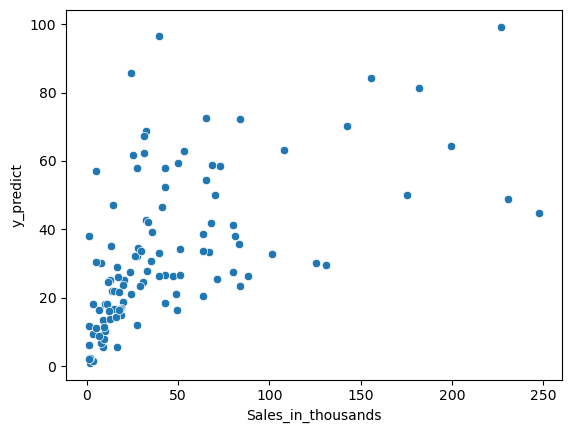

In [111]:
sns.scatterplot( x= train.Sales_in_thousands, y = train.y_predict )

#### 13. Model Validation using Decile Analysis:

In [115]:
# create the deciles in train and test data:

train['Deciles']  = pd.qcut(train.y_predict, 10, labels = range(1,11))
test['Deciles']  = pd.qcut(test.y_predict, 10, labels = range(1,11))

In [119]:
train[['Sales_in_thousands', 'y_predict', 'Deciles']].head(3)

,Sales_in_thousands,y_predict,Deciles
59,73.203,58.648488,9
124,8.982,5.745558,1
41,16.767,29.064516,6


In [120]:
test[['Sales_in_thousands', 'y_predict', 'Deciles']].head(3)

,Sales_in_thousands,y_predict,Deciles
82,5.711,21.826610,4
10,91.561,36.463215,6
130,24.546,87.610321,10


In [122]:
# summarize the data bssed on Decile variable:
train_deciles = train.groupby('Deciles')[['Sales_in_thousands', 'y_predict']].mean().reset_index()
train_deciles

C:\Users\mehak\AppData\Local\Temp\ipykernel_15736\2279079613.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  train_deciles = train.groupby('Deciles')[['Sales_in_thousands', 'y_predict']].mean().reset_index()


,Deciles,Sales_in_thousands,y_predict
0,1,5.677909,5.256326
1,2,15.493844,13.251067
2,3,20.610636,17.829041
3,4,28.566273,22.996396
4,5,45.969455,26.571840
5,6,51.554000,31.075955
6,7,47.027000,35.844921
7,8,94.250636,46.159292
8,9,49.941000,59.486760
9,10,107.582091,78.433932


In [123]:
test_deciles = test.groupby('Deciles')[['Sales_in_thousands', 'y_predict']].mean().reset_index()
test_deciles

C:\Users\mehak\AppData\Local\Temp\ipykernel_15736\539706859.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  test_deciles = test.groupby('Deciles')[['Sales_in_thousands', 'y_predict']].mean().reset_index()


,Deciles,Sales_in_thousands,y_predict
0,1,4.939656,5.177638
1,2,24.983800,12.195316
2,3,15.748200,18.128206
3,4,53.720250,22.551648
4,5,68.156200,28.425114
5,6,88.369464,33.130327
6,7,98.716000,39.477355
7,8,88.916200,43.156990
8,9,37.037200,63.200089
9,10,138.636664,108.280318


#### Other assumptions of Linear Regression Model:

In [125]:
##### 1. Mean of errors = 0:

print(m2.resid.mean())

4.82901180816431e-14


In [127]:
##### 2. Residuals/errors of the model should NOT be correlated with dependant (Y) variable

print(stats.pearsonr(m2.resid, train.lg_sales_in_thousands))

PearsonRResult(statistic=np.float64(0.7214983032858808), pvalue=np.float64(8.78403951684751e-19))


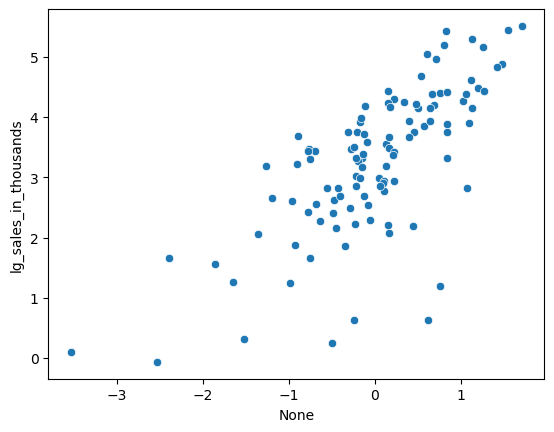

In [130]:
#### 3.  Homoscedasticity of residuals/errors:

sns.scatterplot(x = m2.resid, y = train.lg_sales_in_thousands)
plt.show()

#### Possible reasons for poor accuracies of the model:
1. Small sample 
2. Assumptions of linear/regression modelling are not true for the model in consideration

#### To improve model accuacies:
* ***Possible reasons for model is not validating (over fitting)***
---------------------------------------------------------------------------------------------
1. Data preparation problem (outliers, missings, variable conversions etc. not correct)
2. not included right variables
3. If the data have multicollinerity
4. Including more number of variables 
5. Data size is very low  (ideally we should have 1varaible = 100 obs)
6. The assumptions are not 100% valid
7. The variables are not explaining completely

* ***How to over come this problem?***
--------------------------------------------------------------------------------------------
1. Increase the data/sample size
2. Change the variables - Reiterate the model with different combinations of variables
3. Apply right transformations on X variables such the the linear relationship between Y & X will imrpvove
4. Add dervied variables which can explain Y better
5. Re look into data preparation steps
6. Look at the importance of variables include them in the model
7. Change the modelling technique

******************
There are few techniques can help you to identify important variables (Variable selection - Feature selection)
* F-Regression
* RFE (Recursive feature elimination) - Stepwise regression
******************